In [1]:
import os
import re
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from tensorflow.keras.models import load_model
import tensorflow.keras.metrics as metrics
from sklearn.preprocessing import StandardScaler

In [2]:
# ------------------------------
# Set dataPaths
# ------------------------------
expressionPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01GeneMatrix_gse102556-08052025.csv.gz"
agePath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00Age_gse102556-08052025.csv"
deepPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00deepclock-08192025.h5"
coefPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv"
coefStoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv"
deepStoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00Stochasticdeepclock-08192025.h5"

# -----------------------------
# Set Output Path
outpath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_gse102556-08172025.csv"

# data_type can be "counts" or "fpkm"
data_type = "fpkm"
# Add the GTF file better the one used for counting
gtfPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/03references/02gtf/gencode.v48.chr_patch_hapl_scaff.basic.annotation.gtf.gz"

In [3]:
# ------------------------------
# Load expression data
# ------------------------------
if expressionPath.endswith(".gz"):
    exprData = pd.read_csv(expressionPath, compression='gzip', index_col=0)  # first col = gene names
else:
    exprData = pd.read_csv(expressionPath, index_col=0)

# ------------------------------
# Load age data
# ------------------------------
if agePath.endswith(".gz"):
    age = pd.read_csv(agePath, compression='gzip')
else:
    age = pd.read_csv(agePath)

# ------------------------------
# Validate column names in age
# ------------------------------
age_col_candidates = [c for c in age.columns if c.lower() == "age"]
if not age_col_candidates:
    raise ValueError("No Age column found in age file (expected Age, age, or AGE)")
age_col = age_col_candidates[0]

sample_col_candidates = [c for c in age.columns if c.lower() in ["sampleid", "sample", "id"]]
if not sample_col_candidates:
    raise ValueError("No SampleID column found in age file (expected SampleID, Sample, or ID)")
sample_col = sample_col_candidates[0]

# ------------------------------
# Reorder expression columns to match age SampleID
# ------------------------------
# Keep only samples that exist in both datasets
common_samples = [s for s in age[sample_col] if s in exprData.columns]

if len(common_samples) == 0:
    raise ValueError("No matching samples found between expression data columns and age file")

# Reorder exprData columns to match age order
exprData = exprData[common_samples]
age = age[age[sample_col].isin(common_samples)]

# ------------------------------
# Print shapes and checks
# ------------------------------
print("Expression matrix shape (genes x samples):", exprData.shape)
print("Age table shape:", age.shape)
print("First 5 genes x 5 samples:")
print(exprData.iloc[:5, :5])
print("First 5 age entries:")
print(age[[sample_col, age_col]].head())

Expression matrix shape (genes x samples): (57773, 96)
Age table shape: (96, 2)
First 5 genes x 5 samples:
                  S14.BA11   S17.BA11   S20.BA11   S23.BA11   S28.BA11
ENSG00000000003   3.713370   3.246112   2.544251   3.569386   4.220111
ENSG00000000005   0.146168   0.192151   0.054223   0.062076   0.060779
ENSG00000000419  26.451053  23.580312  25.459108  20.824866  23.429790
ENSG00000000457   4.118387   3.393665   4.138944   3.880850   4.276480
ENSG00000000460   1.265414   1.064180   1.428874   1.376298   1.224328
First 5 age entries:
   SampleID  Age
0  S14.BA11   47
1  S17.BA11   41
2  S20.BA11   31
3  S23.BA11   19
4  S28.BA11   46


In [4]:
# ------------------------------
# Loading models
# ------------------------------
# Load coefficients
df_coef = pd.read_csv(coefPath, index_col=0)
# Convert the single-column DataFrame to a Series
coef_series = pd.Series(df_coef['coef'].values, index=df_coef.index, name='coef')
# Ensure it's a Series
coef_series = pd.Series(coef_series, name='coef')
# Fixed the intercept
intercept = 45.81612584322696

# Deep model
deep_model_filename = deepPath

In [5]:
# Assume coef is your gene list (a pandas Series with gene IDs as index)
coef = df_coef
genes_to_keep = coef.index

# Subset expression data to those genes
missing_genes = [g for g in genes_to_keep if g not in exprData.index]
missing_ratio = len(missing_genes) / len(genes_to_keep)

print(f"Found {len(missing_genes)} missing genes out of {len(genes_to_keep)} "
      f"({missing_ratio:.2%} missing).")

if missing_ratio == 0:
    # Perfect match
    exprData_subset = exprData.loc[genes_to_keep]

elif missing_ratio < 0.2:
    print("⚠️ Missing <20% of genes, proceeding with KNN imputation.")

    # Start with intersection
    exprData_subset = exprData.loc[exprData.index.intersection(genes_to_keep)]

    # Add missing genes as NaN rows
    nan_rows = pd.DataFrame(
        float("nan"),
        index=missing_genes,
        columns=exprData_subset.columns
    )
    exprData_subset = pd.concat([exprData_subset, nan_rows])

    # Reorder to original gene order
    exprData_subset = exprData_subset.loc[genes_to_keep]

    # --- handle rows that are 100% NaN ---
    all_nan_rows = exprData_subset.index[exprData_subset.isna().all(axis=1)]
    if len(all_nan_rows) > 0:
        print(f"Seeding {len(all_nan_rows)} genes that were fully missing...")
        # Fill them with sample-wise mean (can change to 0 if preferred)
        exprData_subset.loc[all_nan_rows] = np.nanmean(exprData_subset.values, axis=0)

    # KNN impute (transpose because KNN works row-wise)
    imputer = KNNImputer(n_neighbors=5)
    imputed = imputer.fit_transform(exprData_subset.T).T

    # ✅ Final expression subset
    exprData_subset = pd.DataFrame(
        imputed,
        index=genes_to_keep,
        columns=exprData_subset.columns
    )

else:
    raise ValueError(f"Too many missing genes ({missing_ratio:.2%}), "
                     f"cannot impute safely.")

print("Final expression subset shape:", exprData_subset.shape)

Found 7 missing genes out of 232 (3.02% missing).
⚠️ Missing <20% of genes, proceeding with KNN imputation.
Seeding 7 genes that were fully missing...
Final expression subset shape: (232, 96)


In [6]:
# -----------------------------------------------------------------
# Define a function for the estimation FPKM of transcriptome data
def counts_to_fpkm(counts: pd.DataFrame, gene_lengths: pd.Series, lengths_in: str = "bp") -> pd.DataFrame:
    """
    Convert raw counts to FPKM.
    counts: genes x samples
    gene_lengths: length per gene (index aligned to counts)
    lengths_in: 'bp' or 'kb'
    """
    assert set(counts.index).issubset(set(gene_lengths.index)), "Gene lengths missing for some genes"  
    # Convert lengths to kilobases
    L = gene_lengths.loc[counts.index].astype(float)
    if lengths_in == "bp":
        L = L / 1e3
    elif lengths_in != "kb":
        raise ValueError("lengths_in must be 'bp' or 'kb'")
        
    # RPK: counts / length_kb
    rpk = counts.divide(L, axis=0)
    
    # FPKM: RPK / (total_mapped_reads_in_millions)
    per_sample_scaler = counts.sum(axis=0) / 1e6
    fpkm = rpk.divide(per_sample_scaler, axis=1)
    
    return fpkm

# -----------------------------------------------------------------
# Define a function for the estimation of gene lengths
def extract_gene_bounds(df: pd.DataFrame, start_col='Start', end_col='End'):
    """
    Extract first start and last end for genes where Start/End columns may contain multiple positions separated by ';'.
    
    Args:
        df: DataFrame with at least 'GeneID', start_col, end_col
        start_col: name of the start column
        end_col: name of the end column
        
    Returns:
        DataFrame with 'GeneID', 'Start', 'End', 'GeneLength'
    """
    starts = []
    ends = []
    for s, e in zip(df[start_col], df[end_col]):
        # Split by ',' and convert to int
        start_vals = [int(x) for x in str(s).split(';') if x.strip().isdigit()]
        end_vals   = [int(x) for x in str(e).split(';') if x.strip().isdigit()]
        if start_vals and end_vals:
            starts.append(min(start_vals))  # first start = smallest
            ends.append(max(end_vals))      # last end = largest
        else:
            starts.append(None)
            ends.append(None)
    
    result = pd.DataFrame({
        'GeneID': df['GeneID'],
        'Start': starts,
        'End': ends
    })
    
    # Compute gene length
    result['GeneLength'] = result['End'] - result['Start'] + 1
    return result

In [7]:
# ------------------------------
# Load GTF file (compressed)
# ------------------------------
# Read GTF, skip comment lines, tab-separated
gtf = pd.read_csv(
    gtfPath,
    compression='gzip',
    sep='\t',
    comment='#',
    header=None,
    names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
)

# ------------------------------
# Function to parse attribute column
# ------------------------------
def parse_attributes(attr):
    d = {}
    for x in attr.split(';'):
        x = x.strip()
        if x == '':
            continue
        key, value = x.split(' ')
        d[key] = value.strip('"')
    return d

# Apply function to extract gene_id and gene_name
gtf['attributes_dict'] = gtf['attribute'].apply(parse_attributes)
gtf['gene_id'] = gtf['attributes_dict'].apply(lambda x: x.get('gene_id'))
gtf['gene_name'] = gtf['attributes_dict'].apply(lambda x: x.get('gene_name'))

# ------------------------------
# Subset only genes
# ------------------------------
genes = gtf[gtf['feature'] == 'gene'].copy()

# Calculate gene length
genes['gene_length'] = genes['end'] - genes['start'] + 1

# Keep only gene_id and gene_length columns
genes_subset = genes[['gene_id', 'gene_length']].copy()

# Optional: reset index
genes_subset.reset_index(drop=True, inplace=True)

In [8]:
# Remove version numbers from gene_id
genes['gene_id'] = genes['gene_id'].apply(lambda x: x.split('.')[0] if pd.notnull(x) else x)
# Keep only gene_id and gene_length columns
genes_subset = genes[['gene_id', 'gene_length']].copy()
genes_subset.reset_index(drop=True, inplace=True)
print(genes_subset.head())

           gene_id  gene_length
0  ENSG00000290825        13774
1  ENSG00000223972         1661
2  ENSG00000310526        16389
3  ENSG00000227232        10191
4  ENSG00000278267           68


In [9]:
# Filter genes_subset to keep only genes in genes_to_keep
genes_subset_filtered = genes_subset[genes_subset['gene_id'].isin(genes_to_keep)].copy()

# Optional: reset index
genes_subset_filtered.reset_index(drop=True, inplace=True)
print("Filtered genes shape:", genes_subset_filtered.shape)
# Calculate median gene length of found genes
median_length = genes_subset_filtered['gene_length'].median()

# Create Series: index = genes_to_keep, values = gene_length
gene_lengths = pd.Series(index=genes_to_keep, dtype=float)
# Fill values for genes that were found
found_mask = genes_to_keep.isin(genes_subset_filtered['gene_id'])
gene_lengths[found_mask] = genes_subset_filtered.set_index('gene_id').loc[genes_to_keep[found_mask], 'gene_length']
# Fill missing genes with median
gene_lengths[~found_mask] = median_length
print(gene_lengths.head())

Filtered genes shape: (231, 2)
ENSG00000006210     12568.0
ENSG00000007516     15802.0
ENSG00000008118     30226.0
ENSG00000008283     14051.0
ENSG00000010818    205230.0
dtype: float64


In [10]:
# ------------------------------
# Convert counts to FPKM if needed
# ------------------------------
if data_type.lower() == "counts":
    # Convert counts to FPKM
    fpkm_matrix = counts_to_fpkm(exprData_subset, gene_lengths, lengths_in="bp")
    print("Converted counts to FPKM.")
elif data_type.lower() == "fpkm":
    # Already FPKM, do nothing
    fpkm_matrix = exprData_subset.copy()
    print("Data is already FPKM, no conversion performed.")
else:
    raise ValueError("data_type must be either 'counts' or 'FPKM'")

Data is already FPKM, no conversion performed.


In [11]:
# -----------------------------------------------------------------
# Standardize by gene (rows)
scaler = StandardScaler(with_mean=True, with_std=True)
expr_z = pd.DataFrame(
    scaler.fit_transform(fpkm_matrix.T).T,  # transpose -> scale -> transpose back
    index=fpkm_matrix.index,  # keep gene names
    columns=fpkm_matrix.columns  # keep sample names
)
expr_z.head()

,S14.BA11,S17.BA11,S20.BA11,S23.BA11,S28.BA11,S32.BA11,S40.BA11,S43.BA11,S45.BA11,S51.BA11,...,S205.BA8_9,S212.BA8_9,S222.BA8_9,S235.BA8_9,S236.BA8_9,S238.BA8_9,S242.BA8_9,S246.BA8_9,S247.BA8_9,S249.BA8_9
ENSG00000006210,-1.754919,-0.549702,-1.076418,0.509103,-1.009958,1.587713,0.278718,-0.065162,-0.036687,-0.943231,...,0.057790,-0.341551,-0.125877,0.612438,-0.204601,0.475368,-0.783377,-0.470468,-0.761423,1.783556
ENSG00000007516,-1.120738,0.291506,-0.516036,0.808171,0.499977,1.258650,1.288512,-0.073948,0.169142,-0.780074,...,-1.169365,-0.137851,-0.952483,-0.704179,-0.131888,-1.092326,0.085870,-0.398745,-0.232949,-0.017376
ENSG00000008118,-1.375715,-0.277710,-2.031381,-0.791417,-0.559419,-0.055179,0.409013,-1.221409,0.386603,-1.381273,...,-0.791223,1.404956,-0.382281,-0.623359,1.334914,-1.470855,0.459040,0.530741,0.272666,1.070753
ENSG00000008283,-0.270834,0.031611,-1.250316,0.037801,1.243168,1.922345,-0.904911,-0.984131,-0.629075,-0.611554,...,1.000777,-1.531267,-0.944780,0.140868,0.946859,-0.437936,0.969263,0.189525,-0.295684,1.345371
ENSG00000010818,-1.470012,-0.013991,-0.675376,1.039047,-0.774477,0.432322,-1.252982,-0.579867,-0.461562,-1.433971,...,-0.235158,1.125141,-0.362787,0.849993,0.153129,-0.283106,-0.573202,0.160604,-0.469521,1.789418


In [12]:
# ------------------------------
# Prepare expression data for excluded samples
# ------------------------------
# Transpose expression subset to samples x genes
X_pred = expr_z.T  # samples x genes

# ------------------------------
# Load the trained deep learning model
# ------------------------------
print(f"Loaded best model from {deep_model_filename}")
deep_model = load_model(deep_model_filename, custom_objects={'mse': metrics.mse})

# ------------------------------
# Predict with the loaded model
# ------------------------------
predicted_values = deep_model.predict(X_pred)

# Flatten to Series for easier handling
predicted_values = pd.Series(
    predicted_values.flatten(),
    index=X_pred.index,
    name='Predicted_Age'
)

Loaded best model from C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00deepclock-08192025.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


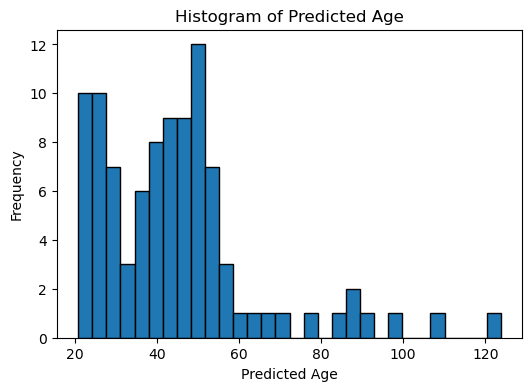

In [13]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_values, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

In [14]:
# ------------------------------
# Predicting using the Elastic Net
# ------------------------------
# Dot product to get predicted age
predicted_age = X_pred.dot(coef_series) + intercept
# Convert to Series
predicted_age = pd.Series(predicted_age, index=X_pred.index, name='Predicted_Age')

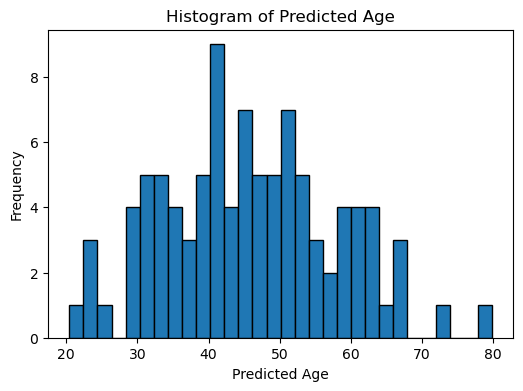

In [15]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_age, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

In [16]:
# ------------------------------
# Predicting using the Stochastic Models
# ------------------------------
# Loading models
# ------------------------------
# Load coefficients
df_coefSto = pd.read_csv(coefStoPath, index_col=0)
# Convert the single-column DataFrame to a Series
coefSto_series = pd.Series(df_coefSto['coef'].values, index=df_coefSto.index, name='coef')
# Ensure it's a Series
coefSto_series = pd.Series(coefSto_series, name='coef')
# Fixed the intercept
intercept = 23.33399503

# ------------------------------
# Load the trained deep learning model
# ------------------------------
# Deep model
deepSto_model_filename = deepStoPath
print(f"Loaded best model from {deepSto_model_filename}")
deepSto_model = load_model(deepSto_model_filename, custom_objects={'mse': metrics.mse})

# ------------------------------
# Predict with the loaded models
# ------------------------------
predicted_values_deepSto = deepSto_model.predict(X_pred)

# Flatten to Series for easier handling
predicted_values_DeepSto = pd.Series(
    predicted_values_deepSto.flatten(),
    index=X_pred.index,
    name='Predicted_DeepSto_Age'
)

# Align columns of X_pred to coefficients index
X_pred_aligned = X_pred.reindex(columns=coefSto_series.index, fill_value=0)

# Dot product (now aligned)
predicted_age_EnSto = X_pred_aligned.dot(coefSto_series) + intercept

# Convert to Series
predicted_age_EnSto = pd.Series(predicted_age_EnSto, index=X_pred.index, name='Predicted_EnSto_Age')

Loaded best model from C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00Stochasticdeepclock-08192025.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


Number of common samples: 96
                                   Actual_Age  Predicted_ElasticNet  \
Actual_Age                           1.000000              0.944128   
Predicted_ElasticNet                 0.944128              1.000000   
Predicted_DeepLearning               0.593909              0.632575   
Predicted_ElasticNet_Stochastic      0.661465              0.670945   
Predicted_DeepLearning_Stochastic    0.518729              0.503330   

                                   Predicted_DeepLearning  \
Actual_Age                                       0.593909   
Predicted_ElasticNet                             0.632575   
Predicted_DeepLearning                           1.000000   
Predicted_ElasticNet_Stochastic                  0.273411   
Predicted_DeepLearning_Stochastic                0.369420   

                                   Predicted_ElasticNet_Stochastic  \
Actual_Age                                                0.661465   
Predicted_ElasticNet                 

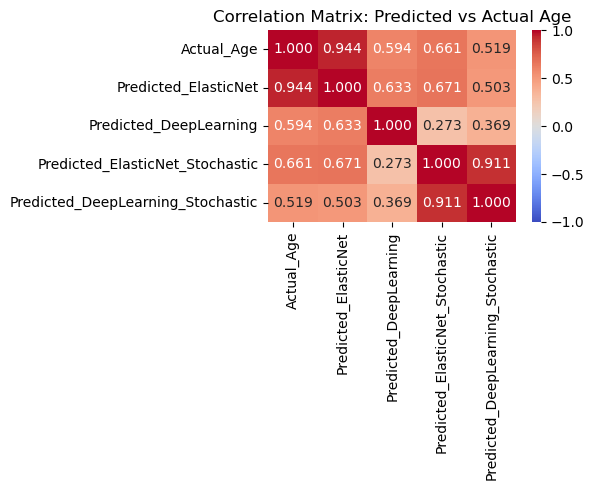

In [17]:
# ------------------------------
# Align samples
# ------------------------------
common_samples = (
    predicted_age.index
    .intersection(predicted_values.index)
    .intersection(predicted_age_EnSto.index)   # add EnSto
    .intersection(predicted_values_DeepSto.index)  # uncomment if you also have DeepSto
    .intersection(age[sample_col])
)
print(f"Number of common samples: {len(common_samples)}")

# Subset each
pred_age_en      = predicted_age.loc[common_samples]
pred_age_dl      = predicted_values.loc[common_samples]
pred_age_en_sto  = predicted_age_EnSto.loc[common_samples]
pred_age_dl_sto  = predicted_values_DeepSto.loc[common_samples]  # if available
age_actual       = age.set_index(sample_col).loc[common_samples, "Age"]

# ------------------------------
# Merge into a single DataFrame
# ------------------------------
df_merge = pd.DataFrame({
    "Actual_Age": age_actual,
    "Predicted_ElasticNet": pred_age_en,
    "Predicted_DeepLearning": pred_age_dl,
    "Predicted_ElasticNet_Stochastic": pred_age_en_sto,
    "Predicted_DeepLearning_Stochastic": pred_age_dl_sto,  # if available
})

# ------------------------------
# Correlation matrix
# ------------------------------
corr_matrix = df_merge.corr()
print(corr_matrix)

# ------------------------------
# Correlation matrix visualize
# ------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1  # Fix color scale
)
plt.title("Correlation Matrix: Predicted vs Actual Age")
plt.tight_layout()
plt.show()

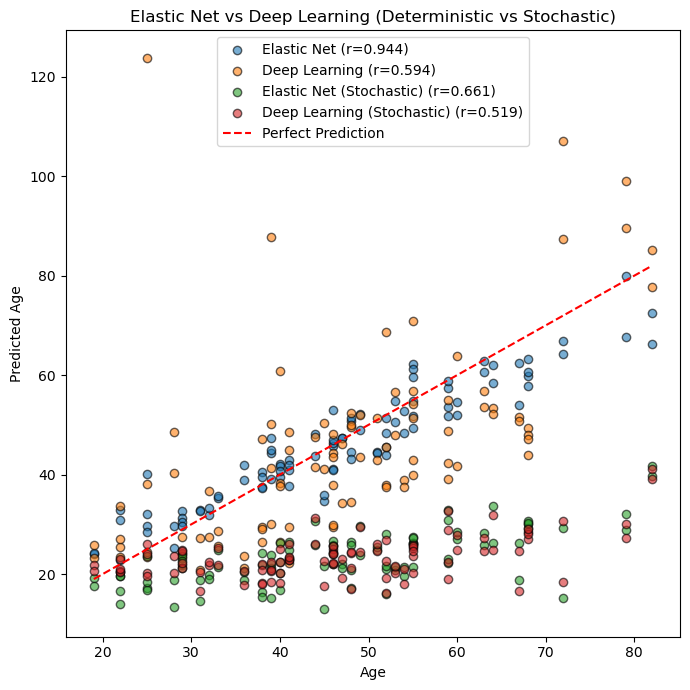

In [18]:
# ------------------------------
# Compute correlations
# ------------------------------
corr_en  = df_merge["Actual_Age"].corr(df_merge["Predicted_ElasticNet"])
corr_dl  = df_merge["Actual_Age"].corr(df_merge["Predicted_DeepLearning"])
corr_en_st = df_merge["Actual_Age"].corr(df_merge["Predicted_ElasticNet_Stochastic"])
corr_dl_st = df_merge["Actual_Age"].corr(df_merge["Predicted_DeepLearning_Stochastic"])

# ------------------------------
# Scatter plot
# ------------------------------
plt.figure(figsize=(7,7))

# Elastic Net
plt.scatter(
    df_merge["Actual_Age"], df_merge["Predicted_ElasticNet"],
    alpha=0.6, edgecolor="k",
    label=f"Elastic Net (r={corr_en:.3f})"
)

# Deep Learning
plt.scatter(
    df_merge["Actual_Age"], df_merge["Predicted_DeepLearning"],
    alpha=0.6, edgecolor="k",
    label=f"Deep Learning (r={corr_dl:.3f})"
)

# Elastic Net Stochastic
plt.scatter(
    df_merge["Actual_Age"], df_merge["Predicted_ElasticNet_Stochastic"],
    alpha=0.6, edgecolor="k",
    label=f"Elastic Net (Stochastic) (r={corr_en_st:.3f})"
)

# Deep Learning Stochastic
plt.scatter(
    df_merge["Actual_Age"], df_merge["Predicted_DeepLearning_Stochastic"],
    alpha=0.6, edgecolor="k",
    label=f"Deep Learning (Stochastic) (r={corr_dl_st:.3f})"
)

# Perfect prediction line
min_age, max_age = df_merge["Actual_Age"].min(), df_merge["Actual_Age"].max()
plt.plot([min_age, max_age], [min_age, max_age], "r--", label="Perfect Prediction")

# Labels
plt.xlabel("Age")
plt.ylabel("Predicted Age")
plt.title("Elastic Net vs Deep Learning (Deterministic vs Stochastic)")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Save to CSV
df_merge.to_csv(outpath, index=True)
print("✅ Saved as age_predictions_merged.csv")

✅ Saved as age_predictions_merged.csv
